### CheatSheet

#### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
from sympy import symbols, Eq, solve, Rational            # Unbekannte, Gleichungen, Brüche
from sympy import solve_univariate_inequality             # Ungleichungen
from sympy import Matrix                                  # Matrizen
from sympy import diff, integrate, oo                     # Ableitungen, Aufleitungen, Unendlich 
from sympy import exp, sqrt, log                          # log(x) = ln(x), log(x,2) = Zweierlogarithmus
from sympy.stats import Binomial, Normal, density, P      # Binomial- und Normalverteilung

In [4]:
from scipy.stats import binom, norm                       # Binomial- und Normalverteilung

#### Variablen definieren


In [2]:
from sympy import symbols
x, y = symbols('x y')

x = symbols('x', positive=True)   # x > 0
y = symbols('y', real=True)       # y ∈ ℝ
z = symbols('z', integer=True)    # z ∈ ℤ
a = symbols('a', real=True, positive=True)  # a ∈ ℝ⁺

# weitere Möglichkeiten
# negative=True, nonzero=True, even=True, odd=True, imaginary=True, prime=True

#### Aufrunden, Abrunden

In [3]:
import math
x = 1.2
math.floor(x)       # abrunden
math.ceil (x)       # aufrunden
print(f'{x:.3f}')   # Mit 3 Stellen hinterm Komma ausgeben    

1.200


#### Simplify
Einen Ausdrück kürzen, ausmultiplizieren, in eine einfachere Form bringen.

In [4]:
from sympy import symbols, simplify
x = symbols('x')
a = (4*x**2 + 8*x) / (2*x)
simplify(a)

2*x + 4

In [5]:
from sympy import symbols, simplify
x = symbols('x')
a = (x + 1)*(x - 1) + x**2
simplify(a) 

2*x**2 - 1

In [6]:
from sympy import symbols, simplify, sin, cos
x = symbols('x')
a = sin(x)**2 + cos(x)**2
simplify(a)

1

In [7]:
from sympy import symbols, simplify, log
x, y = symbols('x y', positive=True)   # ohne positive=True keine Vereinfachung
a = log(x) + log(y)                     
simplify(a) 

log(x*y)

#### Konstanten

In [42]:
from sympy import pi, E
N(pi), N(E)

(3.14159265358979, 2.71828182845905)

#### Einen Ausdruck näherungsweise ausrechnen

Entweder mit N oder .evalf(). N(x) ist die Kurzform für x.evalf().

In [59]:
from sympy import sqrt, N
x = 2*sqrt(5)
x

2*sqrt(5)

In [60]:
N(x)

4.47213595499958

In [61]:
N(x,4)

4.472

In [62]:
x.evalf()

4.47213595499958

In [63]:
x.evalf(4)

4.472

#### Gleichungen 

In [8]:
from sympy import symbols, Eq, solve
x = symbols('x')
g = Eq(3/x + 2, x)    
solve(g,x)

[-1, 3]

Wenn man in den Ergebnisse Brüche erhalten will, kann man *S* oder *Rational* nutzen. Bei *S* reicht es, den Zähler zu markieren.

In [10]:
from sympy import symbols, Eq, solve, S
x = symbols('x')
g = Eq(S(3)/5*x, S(2)/5)    
solve(g,x)

[2/3]

In [11]:
from sympy import symbols, Eq, solve, Rational
x = symbols('x')
g = Eq(Rational(3,5)*x + Rational(4,3), Rational(2,5))    
solve(g,x)

[-14/9]

#### Ungleichungen

In [12]:
from sympy import symbols, solve_univariate_inequality
x = symbols('x')
ug = 8 / (x - 3) < 4
solve_univariate_inequality(ug, x)

((-oo < x) & (x < 3)) | ((5 < x) & (x < oo))

#### Variablen durch Werte ersetzen

In [14]:
from sympy import symbols
x = symbols('x')
f = x*x + 1
f.subs(x,2)

5

In [15]:
from sympy import symbols
x = symbols('x')
x, a, b  = symbols('x a b')
f = a*x + b
f.subs({x:2, a:1, b:3})

5

#### Binomialkoeffizient

In [16]:
import math
math.comb(8,3)         # 8 über 

56

In [17]:
from scipy.special import comb
print(comb(8,3))      
print(comb(8,3,exact=True))

56.0
56


In [19]:
from sympy import symbols, binomial
n, k = symbols('n k')
binomial(n,k)

binomial(n, k)

#### Binomialverteilung: pmf und cdf berechnen

pmf = probability mass function

In [20]:
from scipy.stats import binom
n, p = 8, 0.5
X = binom(n,p)
X.pmf(2), X.cdf(2)

(np.float64(0.10937500000000004), np.float64(0.14453125))

In [22]:
from sympy import symbols
import sympy.stats as stats
n, p, k = symbols('n p k')
X = stats.Binomial('X', n, p) 
stats.density(X)(k)                    # pmf

Piecewise((p**k*(1 - p)**(-k + n)*binomial(n, k), Contains(k, Integers) & (k >= 0) & (k <= n)), (0, True))

In [45]:
from sympy import symbols
import sympy.stats as stats
n = 8 
p = symbols('p')       # geht auch mit p und k
k = 3
X = stats.Binomial('X', n, p)
stats.P(X <= k)

56*p**3*(1 - p)**5 + 28*p**2*(1 - p)**6 + 8*p*(1 - p)**7 + (1 - p)**8

Falls n unbekannt ist, geht der Ansatz von oben nicht. Dann muss man die Summe selbst bilden:

In [24]:
from sympy import symbols, binomial, Sum
p, n, k, i = symbols('p n k i', positive=True)
expr = Sum(binomial(n, i) * p**i * (1 - p)**(n - i), (i, 0, k))
expr

Sum(p**i*(1 - p)**(-i + n)*binomial(n, i), (i, 0, k))

#### Normalverteilung: pdf und cdf berechnen

pdf = probability density function

In [27]:
from scipy.stats import norm
mu, sigma = 0, 1
X = norm(mu,sigma)
X.pdf(2), X.cdf(2)

(np.float64(0.05399096651318806), np.float64(0.9772498680518208))

In [64]:
from sympy import N
from sympy.stats import Normal, density, cdf, E, variance, P
mu, sigma = 0, 1
X = Normal('X', mu, sigma)
density(X)(2).evalf()

0.0539909665131880

In [53]:
P(X <= 2).evalf()     

0.977249868051821

In [52]:
E(X), variance(X)

(0, 1)

In [69]:
m, s, k = symbols('m s k') 
X = Normal('X', m, s)
density(X)(k)

sqrt(2)*exp(-(k - m)**2/(2*s**2))/(2*sqrt(pi)*s)

#### Dichtefunktion der Normalverteilung

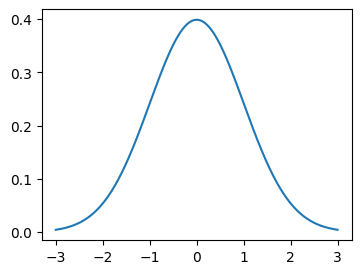

In [36]:
from scipy.stats import norm
N = norm(0,1)       
fig, ax = plt.subplots(figsize=(4,3))
X = np.linspace(-3,3,400)
Y = N.pdf(X)
ax.plot(X,Y)
plt.show()

#### Histogramm der Binomialverteilung


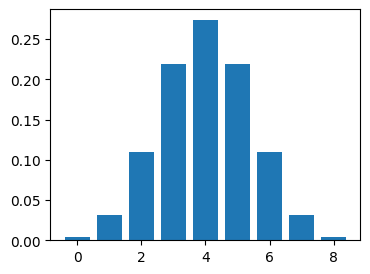

In [60]:
# Histogramm einer Binomialverteilung
from scipy.stats import binom
n, p = 8, 0.5
B = binom(8,0.5)
fig, ax = plt.subplots(figsize=(4,3))
X = np.arange(n+1)
Y = B.pmf(X)
ax.bar(X,Y)
plt.show()

#### Vierfeldertafel

In [1]:
import numpy as np
tafel = np.zeros(9).reshape(3,3)
tafel[2,2] = 1
tafel

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.]])

#### Integration

In [29]:
from sympy import symbols, exp, integrate, oo
x = symbols('x')                    # Variable x
f = 0.25 * exp(-0.25 * x)           # Eine Funktion definieren
F = integrate(f, x)                 # Stammfunktion ermitteln
I = integrate(f, (x, 0, oo))        # Integral von 0 bis +unendlich berechnen
I

1.00000000000000